### Import Packages

Imports the necessary packages for running the code

In [1]:
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib as jl
import BLS_Fit_Functions as BLS

### Experimental Parameters and Search Ranges

The necessary experimental parameters ($\theta_i, \varphi_i, \mathrm{NA}$, see associated publication for definitions/experimental geometry) to calculate spectra and the radius search range to use (spanning from rmin to rmax in increments of rinc). In the associated publication it was found that rinc = 0.01 is optimal for speed and accuracy, but feel free to experiment. ncores is the number of cores to use in parallel computations, set this to whatever is appropriate for your computer. The documentation for the joblib package which is used to parallelise certain portions of the code can be fond here (https://joblib.readthedocs.io/en/stable/). If you do not wish to run things in parallel or do not know how many cores you have at your disposal, set ncores = 1.  

In [2]:
theta_i = np.pi/2 #incident light theta
phi_i = np.pi/2 #incident light phi
NA = 0.42 #numerical aperture of collection lens
rmin = 0.5 #minimum radius
rmax = 2.5 #maximum radius
rinc = 0.005 #increment in radius points
rgrid = np.linspace(rmin,rmax,int(np.round(((rmax-rmin)/rinc)+1))) #grid of radius values used in calculations of spectra
nmin = 1.30 #minimum value of n to consider in constant RI calculations (system dependent, use your intuition, generally 1.35 for aqueous droplets and 1.40 for organics)
nmax = 1.70 #maximum value of n to consider in constant RI calculations (system dependent, use your intuition, generally 1.55 for aqueous droplets and 1.60 for organics)
ninc = 0.005 #increment in n values
ngrid = np.linspace(nmin, nmax,int(np.round(((nmax-nmin)/ninc)+1))) #grid of n values used to generate spectra in size parameter space with constant refractive index
ncores = 24 #number of cores to use in parallel computations
spec_range_lims = [[0.500,0.560],[0.560,0.620],[0.620,0.680],[0.680,0.740],[0.740,0.800]] #limits of wavelength windows used to generate fixed RI points
show_examples = True #Set True to generate example frames demonstrating in detail how approximate and precise parameter retrieval steps. Set False if you do not want to see these.

### Generate Test Spectra

Generate spectra and add noise. This is not part of the normal fitting procedure, these are generated for the purpose of demonstrating how the method works and that it works accurately. Ordinarily, this section should be replaced by code that imports your data in the required format. At the end of your import procedure you need a numpy array called wl which contains the wavelengths at each pixel in your spectrum, and a list called spectra where each list entry is a measured spectrum with the same length as wl. 

In [3]:
noise_amp = 0.05 #set noise amplitude (% of mean of spectrum)
rtrue = np.random.uniform(1.0,2.0) #true radius
Atrue = np.random.uniform(6.5, 7.5) #true amplitude
nutrue = np.random.uniform(9.5, 10.5) #true central frequency
wl = np.linspace(0.4,0.8,1201) #wavelengths to use for calculation
n = BLS.n_osc(1/wl, Atrue, nutrue) #refractive index calculated using the effective oscillator model (https://doi.org/10.1029/2019gl084568)
spectrum_no_noise = BLS.generate_spectrum(rtrue,wl,n,theta_i,phi_i,NA) #generate a spectrum with the true parameters
spectra = [spectrum_no_noise + noise_amp*spectrum_no_noise.mean()*np.random.normal(0,1,len(spectrum_no_noise)) for i0 in range(1000)] #generate 1000 copies of the spectrum with added noise
frameno = np.linspace(1, len(spectra), len(spectra))

#### A Note on Background Subtraction

Throughout this example we will not be applying any background subtraction to our example spectra or the synthetic spectra generated in the course of fitting. This may be necessary, depending on your experimental setup and chosen method of background subtraction. Some discussion of this can be found in the associated publication, where the choice of background subtraction method meant that the slowly varying baseline present in synthetic spectra also had to be removed. There are also cases where background subtraction methods that preserve the slowly varying baseline are used, meaning the baseline does not need to be removed from synthetic spectra even though background subtraction is applied to the measured data. There is no ideal way to do this, this note is simply a warning to exercise caution, as inconsistent choices will affect the final results. 

### Approximate Parameter Retrieval

The first step of the retrival procedure revolves around finding approximate parameters ($r, A, \nu_0$) for the particle in question. This is done as described in detail in the associated publication, with the steps only being summarised here:

- Generate spectra with constant $n$ over the size parameter range defined by the search range for $r$ and $n$ defined at the start and the wavelengths in the measurement
- Choose a series of wavelength subintervals within your spectral range (minimum 3, ideally 4 or 5)
- Calculation correlation between measured spectrum and constant-$n$ spectra in each wavelength interval
- Approximate radius, $r_{\text{app}}$ is the value of $r$ giving the best correlation across all intervals
- $A_{\text{app}}, \nu_{\text{app}}$ determined from fitting the $n$ values giving the highest correlation in each wavelength interval with the approximate $r$ value

#### Generate Constant-$n$ Spectra

In [4]:
xmin = 2*np.pi*rgrid[0]/wl[-1] #minimum size parameter based on radius search space and experimental wavelengths
xmax = 2*np.pi*rgrid[-1]/wl[0] #maximum size parameter based on radius search space and experimental wavelengths
xinc = 0.025 #increment in size parameter values. Best value depends on size range observed but for 1-2 microns 0.02 is sufficient. For radii outside this range you will have to expeirment to find the optimal value
x = np.linspace(xmin, xmax, int(((xmax-xmin)/xinc)+1)) #size parameter values used in constant RI calculations
spectra_constant_n = [BLS.generate_spectra_x(x,nc,theta_i,phi_i,NA) for nc in ngrid] #calculate spectra with constant RI values

#### Retrieve Approximate Parameters

In [5]:
print("Total frames:", len(spectra))
ranges = [(wl >= srl[0]) & (wl <= srl[1]) for srl in spec_range_lims] #booleans corresponding to wavelength ranges lying within each window
wref = np.array([np.mean(srl) for srl in spec_range_lims]) #reference wavelength for each wavelength range (used in fitting)
approx_params = jl.Parallel(n_jobs=ncores, verbose=10)(jl.delayed(BLS.approximate_fit)(se, spectra_constant_n, ranges, wref, rgrid, wl, x, ngrid, np.array([8.0,11.0]), np.array([0.0,0.0]), np.array([20.0,20.0])) for se in spectra) #find approximate radius and oscillator parameters in parallel
rrough = np.asarray(approx_params)[:,0]
Arough = np.asarray(approx_params)[:,1]
nurough = np.asarray(approx_params)[:,2] #extract rough parameters into arrays
binedges = np.linspace(0.0, 20.0, 101)
bincentres = np.array([np.mean(binedges[i0-1:i0+1]) for i0 in range(1,len(binedges))]) #centres of bins
Acounts,_ = np.histogram(Arough, binedges) #histogram of rough A values
nucounts,_ = np.histogram(nurough, binedges) #histogram of rough nu values
Armode = bincentres[Acounts == Acounts.max()] 
nurmode = bincentres[nucounts == nucounts.max()] #modal value of A and nu rough
if len(Armode) > 1: #bug fix for if two bins have same number of counts
    Armode = Armode[0]
if len(nurmode) > 1:
    nurmode = nurmode[0]
Alower = bincentres[(Acounts < 0.1*Acounts.max()) & (bincentres < Armode)].max() 
Aupper = bincentres[(Acounts < 0.1*Acounts.max()) & (bincentres > Armode)].min() #Alower and Aupper are the 10-90 values of the probability distribution function of Arough (approx mean +/- 2*sigma)
nulower = bincentres[(nucounts < 0.1*nucounts.max()) & (bincentres < nurmode)].max()
nuupper = bincentres[(nucounts < 0.1*nucounts.max()) & (bincentres > nurmode)].min() #10-90 values for the distribution of nu values
sigA = 0.5*np.array([Aupper-Armode, Armode-Alower]).mean()
signu = 0.5*np.array([nuupper-nurmode, nurmode-nulower]).mean() #appproximate standard deviations in A and nu
outlier = (Arough < Armode-3*sigA) | (Arough > Armode+3*sigA) | (nurough < nurmode-3*signu) | (nurough > nurmode+3*signu) #find outliers
Armean = np.mean(Arough[~outlier])
nurmean = np.mean(nurough[~outlier]) #calculate mean values of A and nu excluding outliers
rsmooth = sp.signal.savgol_filter(rrough, 100, 1) #smooth retrieved radii
rstd = np.sqrt((1/len(rrough))*np.einsum('i->',(rrough-rsmooth)**2)) #standard 
routlier = outlier | (rrough < rsmooth-3*rstd) | ((rrough > rsmooth+3*rstd))
rsmooth = sp.signal.savgol_filter(rrough[~routlier], 100, 1) #smooth again without outliers
rsmooth = np.interp(frameno, frameno[~routlier], rsmooth) #interpolate to fill in values that were outliers with sensible values from smoothing

Total frames: 1000


[Parallel(n_jobs=24)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    4.7s
[Parallel(n_jobs=24)]: Done  13 tasks      | elapsed:    5.1s
[Parallel(n_jobs=24)]: Done  24 tasks      | elapsed:    5.3s
[Parallel(n_jobs=24)]: Done  37 tasks      | elapsed:    9.0s
[Parallel(n_jobs=24)]: Done  50 tasks      | elapsed:   12.7s
[Parallel(n_jobs=24)]: Done  65 tasks      | elapsed:   13.1s
[Parallel(n_jobs=24)]: Done  80 tasks      | elapsed:   16.8s
[Parallel(n_jobs=24)]: Done  97 tasks      | elapsed:   20.3s
[Parallel(n_jobs=24)]: Done 114 tasks      | elapsed:   21.1s
[Parallel(n_jobs=24)]: Done 133 tasks      | elapsed:   25.1s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:   28.9s
[Parallel(n_jobs=24)]: Done 173 tasks      | elapsed:   32.7s
[Parallel(n_jobs=24)]: Done 194 tasks      | elapsed:   36.4s
[Parallel(n_jobs=24)]: Done 217 tasks      | elapsed:   40.2s
[Parallel(n_jobs=24)]: Done 240 tasks      | elapsed:  

#### Plots

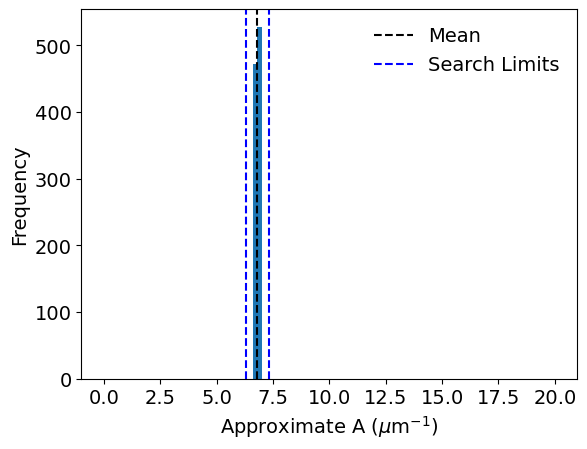

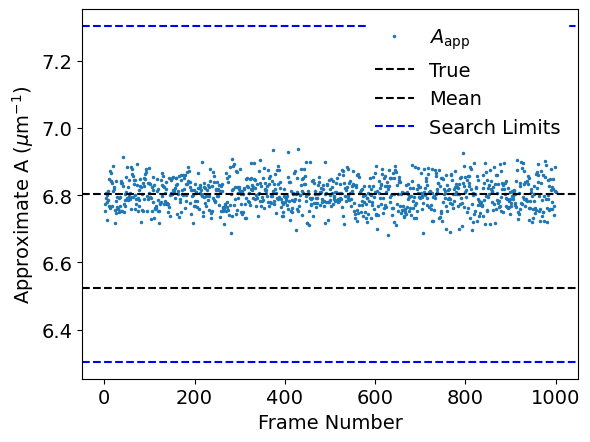

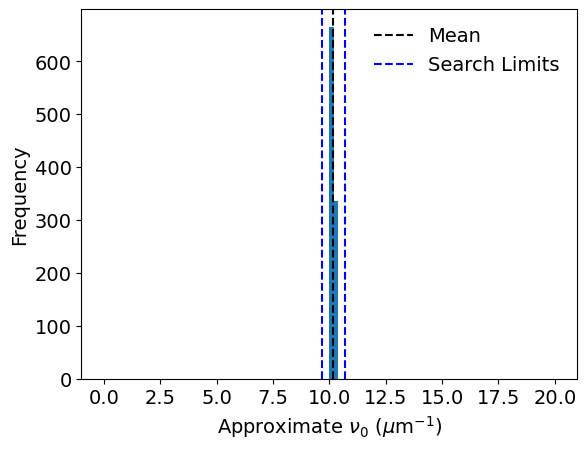

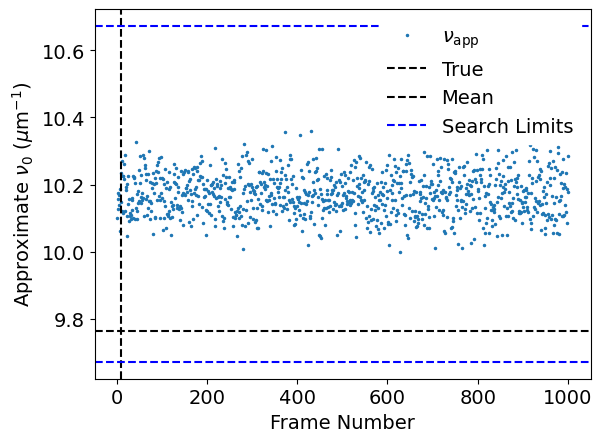

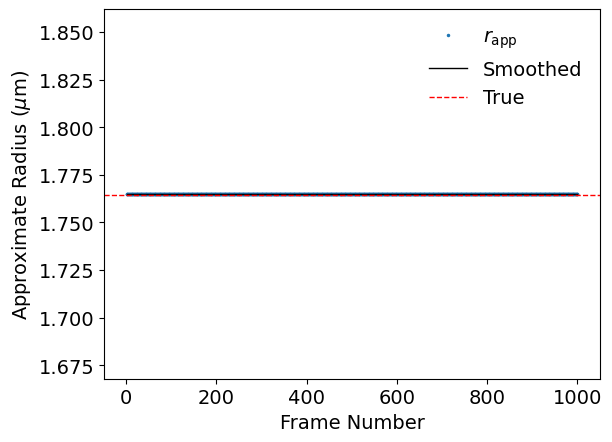

In [ ]:
plt.hist(Arough, binedges)
plt.axvline(Armean, 0, 1, linestyle='--', color='k', label='Mean')
plt.axvline(Armean+0.5, 0, 1, linestyle='--', color='b', label=r'Search Limits')
plt.axvline(Armean-0.5, 0, 1, linestyle='--', color='b')
plt.xlabel(r'Approximate A ($\mu$m$^{-1}$)', fontsize=14)
plt.ylabel(r'Frequency', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(frameno, Arough, '.', markersize=3, label=r'$A_\text{app}$')
plt.axhline(Atrue, 0, 1, linestyle='--', color='r', label='True')
plt.axhline(Armean, 0, 1, linestyle='--', color='k', label='Mean')
plt.axhline(Armean+0.5, 0, 1, linestyle='--', color='b', label=r'Search Limits')
plt.axhline(Armean-0.5, 0, 1, linestyle='--', color='b')
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Approximate A ($\mu$m$^{-1}$)', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.hist(nurough, binedges)
plt.axvline(nurmean, 0, 1, linestyle='--', color='k', label='Mean')
plt.axvline(nurmean+0.5, 0, 1, linestyle='--', color='b', label=r'Search Limits')
plt.axvline(nurmean-0.5, 0, 1, linestyle='--', color='b')
plt.xlabel(r'Approximate $\nu_0$ ($\mu$m$^{-1}$)', fontsize=14)
plt.ylabel(r'Frequency', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(frameno, nurough, '.', markersize=3, label=r'$\nu_\text{app}$')
plt.axhline(nutrue, 0, 1, linestyle='--', color='r', label='True')
plt.axhline(nurmean, 0, 1, linestyle='--', color='k', label='Mean')
plt.axhline(nurmean+0.5, 0, 1, linestyle='--', color='b', label=r'Search Limits')
plt.axhline(nurmean-0.5, 0, 1, linestyle='--', color='b')
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Approximate $\nu_0$ ($\mu$m$^{-1}$)', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(frameno, rrough, '.', markersize=3, label=r'$r_\text{app}$')
plt.plot(frameno, rsmooth, 'k', linewidth=1, label='Smoothed')
plt.axhline(rtrue, 0, 1, color='r', linestyle='--', linewidth=1, label=True)
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Approximate Radius ($\mu$m)', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### Example Frame

Example graphs for a random frame intended  to illustrate how exactly the approximate retrieval method works. Can be turned off by setting show_examples = False at the top of the notebook.

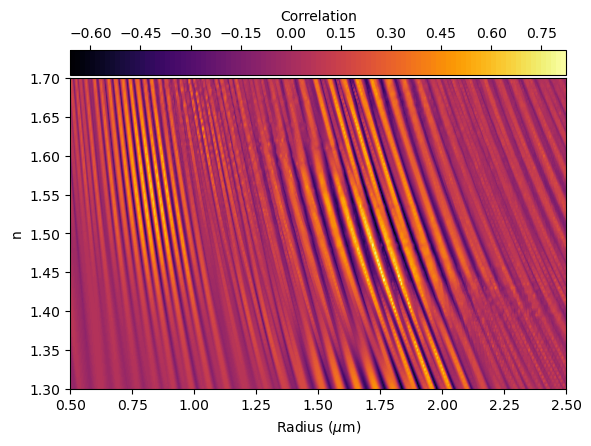

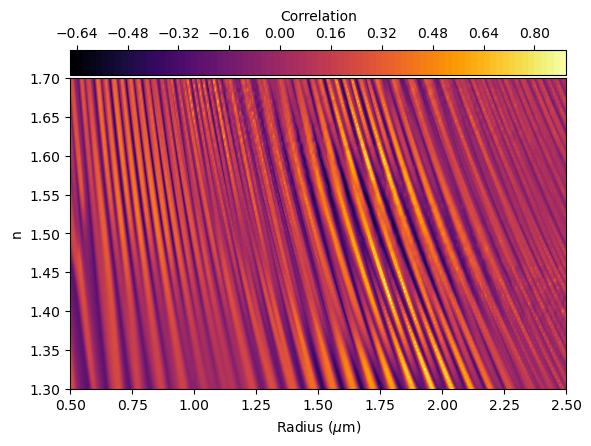

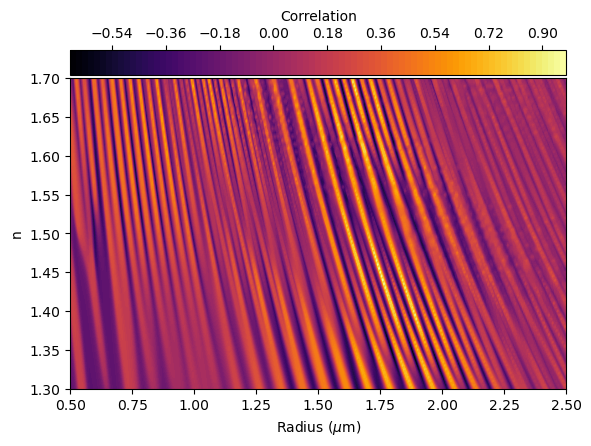

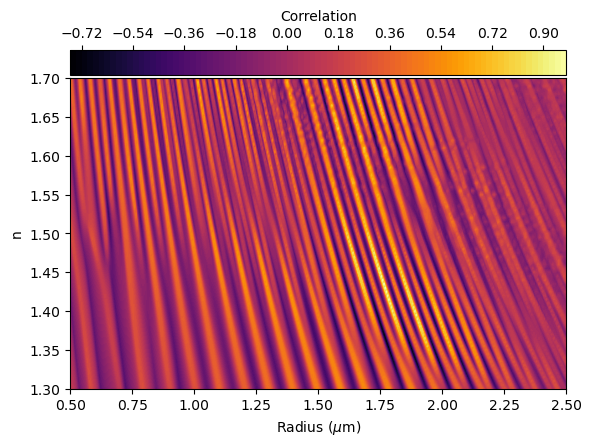

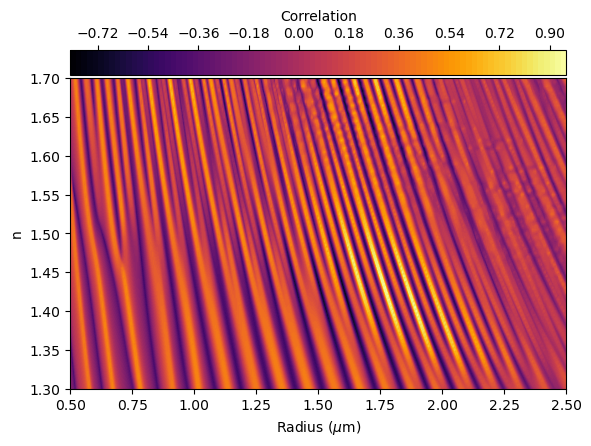

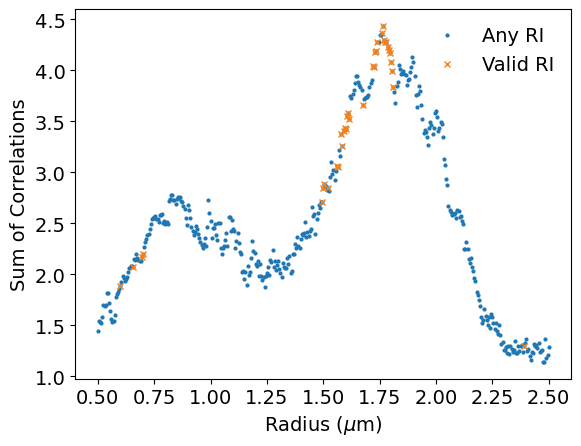

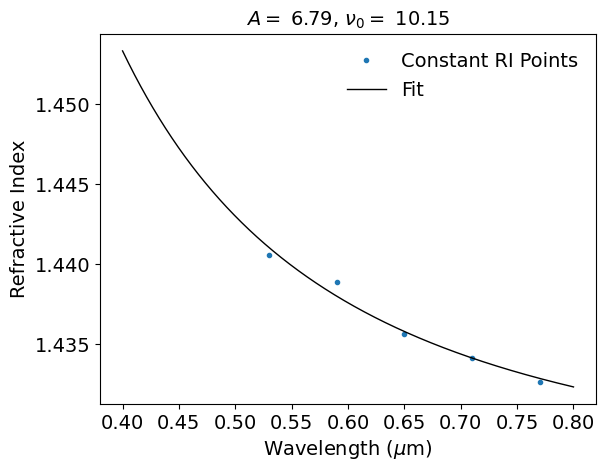

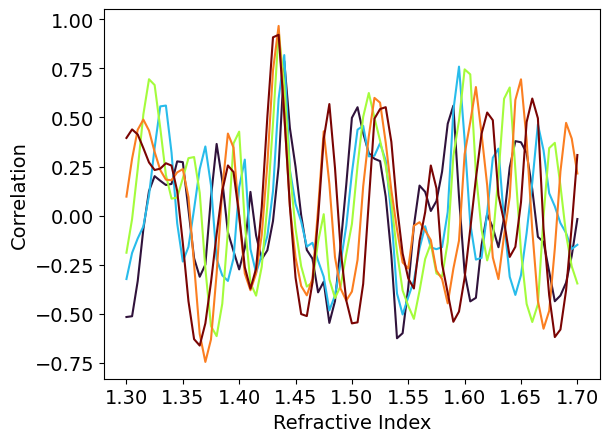

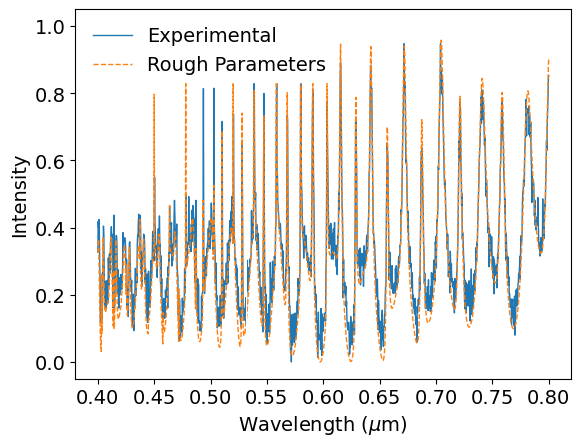

In [ ]:
if show_examples:
    colours = BLS.colour_subset(len(ranges),'turbo') #generate necessary number of colours for graphs
    ind = np.random.randint(0,len(spectra)-1) #choose random index for illustrative purposes 
    spec = spectra[ind] #get corresponding spectrum
    corr = np.zeros((len(spectra_constant_n), len(rgrid), len(spec_range_lims))) #space for correlations
    for i1, sc in enumerate(spectra_constant_n):
        for i2, rg in enumerate(rgrid):
            xint = ((wl/(2*np.pi))**2)*np.interp(2*np.pi*rg/wl, x, sc) #interpolate calculated spectra to x values produced by i2th value of radius
            corr[i1,i2,:] = [BLS.Pearson_CC(spec[ri], xint[ri]) for ri in ranges] #calculate correlation coefficient for spectrum in each wavelength range
    cmaxima = corr.max(axis=0) #maximum correlations for each radius in each range
    nmaxima = np.zeros_like(cmaxima, dtype=int) #space for maxima in RI for each radius
    for i1 in range(len(rgrid)):
        nmaxima[i1,:] = np.squeeze([np.where(corr[:,i1,i2] == corr[:,i1,i2].max())[0] for i2 in range(len(ranges))])
    valid = (nmaxima[:,0] == nmaxima.max(axis=1)) & (nmaxima[:,-1] == nmaxima.min(axis=1))#determine whether shortest wavelength n is maximum (= valid) or not (= not valid)
    corrtot = np.einsum('ij->i', cmaxima) #sum maximum correlations in each range for each radius
    maxtot = corrtot == corrtot[valid].max() #find maximum correlation with valid RI points
    nmaxind = np.squeeze(nmaxima[corrtot == corrtot[valid].max()]) #indices of maxima in n for radius with maximum valid correlation
    wref = wref[(nmaxind != 0) & (nmaxind != len(ngrid)-1)] #remove reference wavelength values at extrema of RI grid (can't be parabolically interpolated)
    nmaxind = nmaxind[(nmaxind != 0) & (nmaxind != len(ngrid)-1)] #get rid of any maxima at extrema of RI range (causes next line to fail)
    npts = np.squeeze([BLS.parabolic_interpolation(ngrid[nmi-1:nmi+2], corr[nmi-1:nmi+2,maxtot,i1]) for i1, nmi in enumerate(nmaxind)]) #parabolic interpolation on RI maxima t oget more accurate values
    res, _ = sp.optimize.curve_fit(BLS.n_osc, 1/wref, npts, p0=[10.0,10.0], bounds=([0.0,0.0], [20.0,20.0]), max_nfev=1e5) #fit constant RI points to oscillator model to get rough oscillator parameters
    for i1 in range(len(ranges)):
        plt.contourf(rgrid, ngrid, corr[:,:,i1], 100, cmap='inferno')
        plt.xlabel(r'Radius ($\mu$m)')
        plt.ylabel("n")
        plt.colorbar(location="top", pad=0.01, label='Correlation')
        plt.show()
    plt.plot(rgrid, corrtot, '.', markersize=4, label='Any RI')
    plt.plot(rgrid[valid], corrtot[valid], 'x', markersize=4, label='Valid RI')
    plt.xlabel(r'Radius ($\mu$m)', fontsize=14)
    plt.ylabel("Sum of Correlations", fontsize=14)
    plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    plt.plot(wref, npts, '.', markersize=6, label='Constant RI Points')
    plt.plot(wl, BLS.n_osc(1/wl, res[0], res[1]), 'k', linewidth=1, label='Fit')
    plt.xlabel(r'Wavelength ($\mu$m)', fontsize=14)
    plt.ylabel("Refractive Index", fontsize=14)
    plt.title(r'$A =$ ' + str(np.round(Arough[ind],2)) +  r', $\nu_0 =$ ' + str(np.round(nurough[ind],2)), fontsize=14)
    plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    for i1 in range(len(ranges)):
        plt.plot(ngrid, corr[:,maxtot,i1], color=colours[i1,:])
    plt.xlabel("Refractive Index", fontsize=14)
    plt.ylabel("Correlation", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()
    plt.plot(wl, spectra[ind], linewidth=1, label='Experimental')
    plt.plot(wl, BLS.generate_spectrum(rrough[ind], wl, BLS.n_osc(1/wl, Arough[ind], nurough[ind], theta_i, phi_i, NA)), linewidth=1, linestyle='--', label='Rough Parameters')
    plt.axvspan(wl[wl < 0.473].max(), wl[wl > 0.473].min(), 0.01, 0.99, facecolor='white', alpha=1, zorder=3)
    plt.axvspan(wl[wl < 0.532].max(), wl[wl > 0.532].min(), 0.01, 0.99, facecolor='white', alpha=1, zorder=4)
    plt.xlabel(r'Wavelength ($\mu$m)', fontsize=14)
    plt.ylabel("Intensity", fontsize=14)
    plt.legend(facecolor='white', edgecolor='white', framealpha=1,fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.show()

### Precise Parameter Retrieval

This stage of the code refines the approximate particle parameters $(r_\text{app}, A_\text{app}, \nu_\text{app})$ found in the previous step of the code. There are two main stages to this procdeure: calculation of spectra spanning the necessary search space, then an interpolation procedure to find precise parameters using these spectra and the approximate parameters determined above. Further details are found below in the corresponding subsections.

#### Calculate Necessary Spectra

Calculates spectra over a reduced search space, the limits of which are determined by the approximate fitting step. Specifically, for radii, values span the minimum of $r_\text{app} - 20$ nm to the maximum of $r_\text{app} + 20$ nm in increments of 10 nm, and for $A_\text{app}$ and $\nu_\text{app}$ we take the mean of each $\pm 0.5$ $\mu\text{m}^{-1}$ with increments of $0.067$ and $0.02$, respectively.

In [8]:
rpts = rgrid[(rgrid >= np.round(rsmooth.min(),2)-0.02) & (rgrid <= np.round(rsmooth.max(),2)+0.02)]  #set radius values for which spectra are to be calculated
Apts = np.linspace(np.round(Armean-0.5,1), np.round(Armean+0.5,1), 16) #set A values to use in calculations 
nupts = np.linspace(np.round(nurmean-0.5,1), np.round(nurmean+0.5,1), 51) #set nu0 values to use in calculations
allcombs = np.meshgrid(Apts,nupts,indexing='ij') #all combinations of A and nu
OPs = np.column_stack((np.ravel(allcombs[0]),np.ravel(allcombs[1]))) #reshape into array with two columns [A, nu]
RI = [BLS.n_osc(1/wl, OPs[i0,0], OPs[i0,1]) for i0 in range(np.shape(OPs)[0])]  #refractive index distribution for each combination of oscillator parameters
Aind = np.zeros(np.shape(RI)[0])
nuind = np.zeros_like(Aind) #space for indices corresponding to each unique A and nu
for i0 in range(len(Apts)):
    Aind[OPs[:,0] == Apts[i0]] = i0
for i0 in range(len(nupts)):
    nuind[OPs[:,1] == nupts[i0]] = i0 #assign indices to corresponding A, nu values
specgrid = [] #space for synthetic spectra
for i0, r in enumerate(rpts):
    print("Calculation", i0+1, "of", len(rpts), "running...") #For progress-tracking purposes
    st = time.time() #start timer for i0th radius 
    speci = jl.Parallel(n_jobs=ncores, verbose=0)(jl.delayed(BLS.generate_spectrum)(r,wl,n,theta_i,phi_i,NA) for n in RI) #calculate spectra for each radius with each combination of oscillator parameters
    specmat = np.zeros((len(Apts), len(nupts), len(wl))) #space for matrix containing spectra for each combination of A and nu
    for i1, s in enumerate(speci):
        specmat[int(Aind[i1]),int(nuind[i1]),:] = s #put calculated spectra into matrix correctly
    specgrid.append(specmat) #append spectra to list
    print("Complete in", time.time()-st, "s.") #print completion message and time

Calculation 1 of 11 running...
Complete in 32.6500039100647 s.
Calculation 2 of 11 running...
Complete in 32.9380898475647 s.
Calculation 3 of 11 running...
Complete in 33.34422993659973 s.
Calculation 4 of 11 running...
Complete in 32.93073010444641 s.
Calculation 5 of 11 running...
Complete in 32.86194658279419 s.
Calculation 6 of 11 running...
Complete in 32.821852684020996 s.
Calculation 7 of 11 running...
Complete in 32.95591640472412 s.
Calculation 8 of 11 running...
Complete in 33.19566226005554 s.
Calculation 9 of 11 running...
Complete in 32.89863419532776 s.
Calculation 10 of 11 running...
Complete in 33.02639293670654 s.
Calculation 11 of 11 running...
Complete in 32.97189712524414 s.


#### Precise Parameter Retrieval

We retrieve precise particle parameters $r_\text{fit}, A_\text{fit}, \nu_\text{fit}$ by interpolating between synthetic spectra close to the approximate solution found in the previous step. Again, this is explained in detail in the associated publication and is only summarised here. For each measured spectrum, we:

- Find the radius in `rgrid` closest to the smoothed value of $r_\text{app}$ for this frame, and select this radius along with two radius grid points either side as the radius search space
- For the first radius in the search space, calculate the Pearson sample correlation coefficient between the measured spectrum and each synthetic spectrum (i.e. spectra calculated using the radius value and every combination of $A, \nu_0$)
- From the resulting correlation map, find the maxima in correlation, $c_\text{max}$, and their coordinates in $(A, \nu_0)$-space, $(A_\text{max}, \nu_\text{max})$
- After repeating for each radius in the search space, interpolate between $c_\text{max}$ values as a function of $r$ to find the value of $r$ giving the maximum correlation: this is the precise radius $r_\text{fit}$
- Interpolate between $A_\text{max}$ and $\nu_\text{max}$ values as a function of radius to $r_\text{fit}$ to get $A_\text{fit}, \nu_\text{fit}$

In [9]:
rfit = np.zeros_like(rsmooth)
Afit = np.zeros_like(rfit)
nufit = np.zeros_like(rfit) #space for fit values of radius, amplitude and central frequency
corrfit = np.zeros_like(rfit)
fittime = np.zeros_like(rfit) #times taken to perform fits
for i0, speci in enumerate(spectra):
    st = time.time()
    centrepoint = np.searchsorted(rpts, rsmooth[i0]) #find radius grid point which is rough guess
    if (centrepoint > 1) & (centrepoint < len(rpts)-2):
        rrange = np.linspace(centrepoint-2,centrepoint+2,5,dtype=int) #take two points either side of rough guess
    elif centrepoint <= 1: 
        rrange = np.linspace(0,4,5,dtype=int) #if only one point on lower side of rough guess, take five lowest radius points
    elif centrepoint >= len(rpts)-2: 
        rrange = np.linspace(-5,-1,5,dtype=int) #if only one point on higher side of rough guess, take five highest points
    rptsi = rpts[rrange] #take necessary radius values from grid points
    specgridred = [] #take necessary spectra from calculated grid points
    for rr in rrange:
        specgridred.append(specgrid[rr])
    cpeak = np.zeros_like(rptsi)
    Apeak = np.zeros_like(cpeak)
    nupeak = np.zeros_like(cpeak) #space for integrated correlation, and values of A and nu at maximum for each radius
    for i1 in range(len(rptsi)):
        corr = np.zeros((len(Apts),len(nupts))) #space for correlations
        for i2 in range(len(Apts)):
            for i3 in range(len(nupts)):
                corr[i2,i3] = BLS.Pearson_CC(speci, np.squeeze(specgridred[i1][i2,i3,:])) #correlation between experimental spectrum and selected calculated spectrum
        Amaxima = []
        numaxima = []
        cmaxima = [] #space for A and nu coordinates of correlation 
        for i2 in range(len(Apts)): #cycle through rows of array
            if (corr[i2,:].max() != corr[i2,:][0]) & (corr[i2,:].max() != corr[i2,:][-1]): #if maximum of row isn't at either edge
                maxcoord = np.argmax(corr[i2,:]) #find index of maximum correlation point
                numax, cmax = BLS.parabolic_interpolation_xy(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2]) #use parabolic interpolation to find maximum correlation and nu value at which it occurs
                Amaxima.append(Apts[i2])
                numaxima.append(numax)
                cmaxima.append(cmax) #put A, nu and correlation into arrays
        if len(Amaxima) == 0: #bug fix for if no maxima found
            maxcoord = np.unravel_index(np.argmax(corr), np.shape(corr))
            Amaxima.append(Apts[maxcoord[0]])
            numaxima.append(nupts[maxcoord[1]])
            cmaxima.append(corr[maxcoord])
        Amaxima = np.array(Amaxima)
        numaxima = np.array(numaxima)
        cmaxima = np.array(cmaxima) #change lists to arrays (necessary for argsort to work)
        if cmaxima.max() > 0:
            primary = cmaxima > 0.9*cmaxima.max()
        else:
            primary = cmaxima > 1.1*cmaxima.max()
        Amaxima = Amaxima[primary]
        numaxima = numaxima[primary]
        cmaxima = cmaxima[primary] #sometimes multiple diagonal peaks appear in search space, lines 40--43 remove any points associated with those
        if (len(cmaxima) >= 5) & (np.sum(numaxima == np.sort(numaxima)) == len(numaxima)):
            nufine = np.linspace(numaxima.min(),numaxima.max(),int(((numaxima.max()-numaxima.min())/0.01)+1))
            cfit = sp.interpolate.make_smoothing_spline(numaxima, cmaxima, lam=1e-6)
            cinterp = cfit(nufine)
            maxind = np.argmax(cinterp)
            cpeak[i1] = cinterp[maxind]
            Apeak[i1] = np.interp(nufine[maxind], numaxima, Amaxima)
            nupeak[i1] = nufine[maxind]
        elif (len(cmaxima) <= 4) | (np.sum(numaxima == np.sort(numaxima)) < len(numaxima)):
            maxind = np.argmax(cmaxima)
            cpeak[i1] = cmaxima[maxind]
            Apeak[i1] = Amaxima[maxind]
            nupeak[i1] = numaxima[maxind]
    while ((cpeak[0] == cpeak.max()) | (cpeak[-1] == cpeak.max())) & (rptsi[cpeak == cpeak.max()] != rpts.min()) & (rptsi[cpeak == cpeak.max()] != rpts.max()): #if maximum interpolated correlation is at extreme of radius range, rough guess was probably a little off, so repeat but centred around maximum point from first search
        centrepoint = np.searchsorted(rpts, rptsi[cpeak == cpeak.max()])[0]
        if (centrepoint > 1) & (centrepoint < len(rpts)-2):
            rrange = np.linspace(centrepoint-2,centrepoint+2,5,dtype=int)
        elif centrepoint <= 1: 
            rrange = np.linspace(0,4,5,dtype=int)
        elif centrepoint >= len(rpts)-2: 
            rrange = np.linspace(-5,-1,5,dtype=int)
        rptsi = rpts[rrange] #take necessary radius values from grid points
        specgridred = [] #take necessary spectra from calculated grid points
        for rr in rrange:
            specgridred.append(specgrid[rr])
        cpeak = np.zeros_like(rptsi)
        Apeak = np.zeros_like(cpeak)
        nupeak = np.zeros_like(cpeak)
        for i1 in range(len(rptsi)):
            corr = np.zeros((len(Apts),len(nupts))) #space for correlations
            for i2 in range(len(Apts)):
                for i3 in range(len(nupts)):
                    corr[i2,i3] = BLS.Pearson_CC(speci, specgridred[i1][i2,i3,:]) #correlation between experimental spectrum and selected calculated spectrum
            Amaxima = []
            numaxima = []
            cmaxima = []
            for i2 in range(len(Apts)):
                if (corr[i2,:].max() != corr[i2,:][0]) & (corr[i2,:].max() != corr[i2,:][-1]):
                    maxcoord = np.argmax(corr[i2,:])
                    numax, cmax = BLS.parabolic_interpolation_xy(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2])
                    Amaxima.append(Apts[i2])
                    numaxima.append(numax)
                    cmaxima.append(cmax)
            if len(Amaxima) == 0:
                maxcoord = np.unravel_index(np.argmax(corr), np.shape(corr))
                Amaxima.append(Apts[maxcoord[0]])
                numaxima.append(nupts[maxcoord[1]])
                cmaxima.append(corr[maxcoord])
            Amaxima = np.array(Amaxima)
            numaxima = np.array(numaxima)
            cmaxima = np.array(cmaxima) #change lists to arrays (necessary for argsort to work)
            if cmaxima.max() > 0:
                primary = cmaxima > 0.9*cmaxima.max()
            else:
                primary = cmaxima > 1.1*cmaxima.max()
            Amaxima = Amaxima[primary]
            numaxima = numaxima[primary]
            cmaxima = cmaxima[primary]
            if (len(cmaxima) >= 5) & (np.sum(numaxima == np.sort(numaxima)) == len(numaxima)):
                nufine = np.linspace(numaxima.min(),numaxima.max(),int(((numaxima.max()-numaxima.min())/0.01)+1))
                cfit = sp.interpolate.make_smoothing_spline(numaxima, cmaxima, lam=1e-6)
                cinterp = cfit(nufine)
                maxind = np.argmax(cinterp)
                cpeak[i1] = cinterp[maxind]
                Apeak[i1] = np.interp(nufine[maxind], numaxima, Amaxima)
                nupeak[i1] = nufine[maxind]
            elif (len(cmaxima) <= 4) | (np.sum(numaxima == np.sort(numaxima)) < len(numaxima)):
                maxind = np.argmax(cmaxima)
                cpeak[i1] = cmaxima[maxind]
                Apeak[i1] = Amaxima[maxind]
                nupeak[i1] = numaxima[maxind]
    maxc = np.argmax(cpeak) #find index of maximum correlation point
    if (maxc != 0) & (maxc != len(rptsi)-1):
        rmax, cmax = BLS.parabolic_interpolation_xy(rptsi[maxc-1:maxc+2], cpeak[maxc-1:maxc+2]) #interpolate integrated correlation points to find fitted radius
    else:
        cmax = cpeak[maxc]
        rmax = rptsi[maxc]
    rfit[i0] = rmax #put fitted radius into array
    Amaxfit = sp.interpolate.make_smoothing_spline(rptsi, Apeak, lam=1e-10) #interpolate A maxima as function of radius
    numaxfit = sp.interpolate.make_smoothing_spline(rptsi, nupeak, lam=1e-10) #interpolate nu maxima as function of radius
    corrfit[i0] = cmax
    Afit[i0] = Amaxfit(rmax)
    nufit[i0] = numaxfit(rmax) #put A and nu values at best-fit radius into array
    fittime[i0] = time.time()-st #put time for fit into array
    print("Frame", i0+1, "of", len(spectra), "complete in", time.time()-st, "s.")
rmean = np.mean(rfit) #smooth retrieved radii
runcert = np.std(rfit) #residuals between smoothed radius and fits
Amean = np.mean(Afit) #mean of fitted A values
numean = np.mean(nufit) #mean of fitted nu values
Auncert = np.std(Afit) #uncertainty in mean A
nuuncert = np.std(nufit) #uncertainty in mean nu

Frame 1 of 1000 complete in 0.053398847579956055 s.
Frame 2 of 1000 complete in 0.05172562599182129 s.
Frame 3 of 1000 complete in 0.050252676010131836 s.
Frame 4 of 1000 complete in 0.05104565620422363 s.
Frame 5 of 1000 complete in 0.05029129981994629 s.
Frame 6 of 1000 complete in 0.05074787139892578 s.
Frame 7 of 1000 complete in 0.05041694641113281 s.
Frame 8 of 1000 complete in 0.049994707107543945 s.
Frame 9 of 1000 complete in 0.0509800910949707 s.
Frame 10 of 1000 complete in 0.050383806228637695 s.
Frame 11 of 1000 complete in 0.050783634185791016 s.
Frame 12 of 1000 complete in 0.05053091049194336 s.
Frame 13 of 1000 complete in 0.05075788497924805 s.
Frame 14 of 1000 complete in 0.05087614059448242 s.
Frame 15 of 1000 complete in 0.05047798156738281 s.
Frame 16 of 1000 complete in 0.051294565200805664 s.
Frame 17 of 1000 complete in 0.05021262168884277 s.
Frame 18 of 1000 complete in 0.049953460693359375 s.
Frame 19 of 1000 complete in 0.05068492889404297 s.
Frame 20 of 100

#### Plots

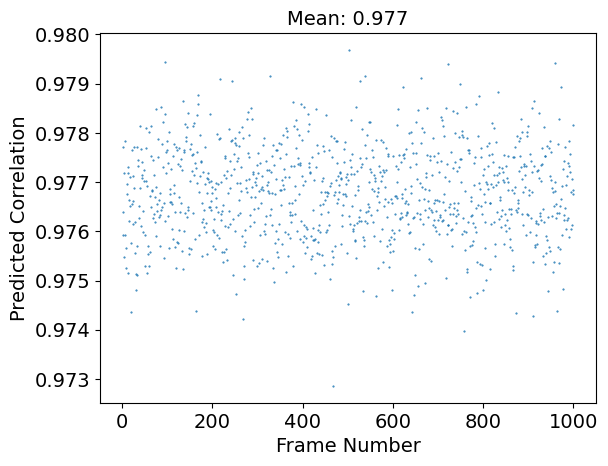

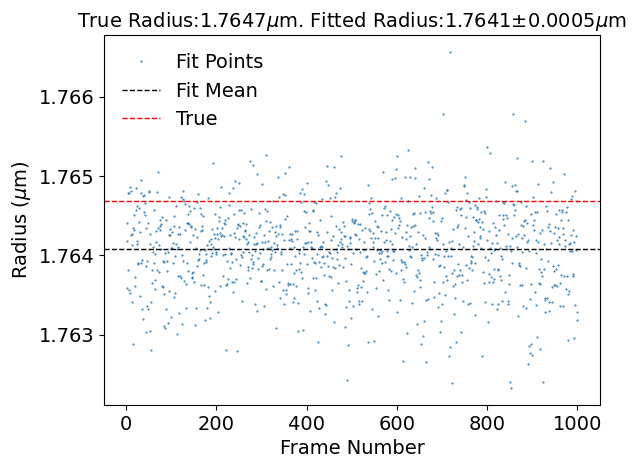

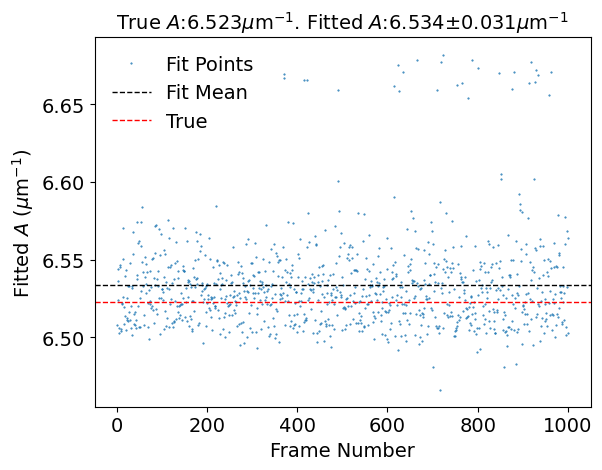

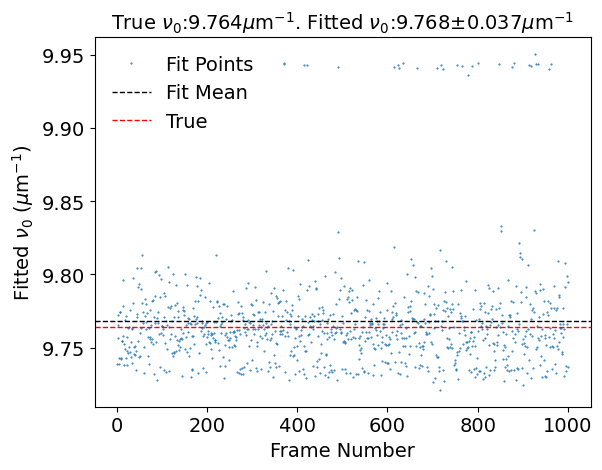

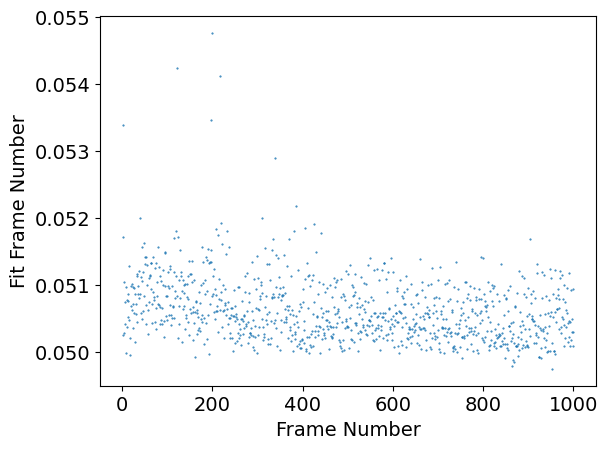

In [10]:
plt.plot(frameno, corrfit, '.', markersize=1, mec=None)
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Predicted Correlation', fontsize=14)
plt.title(r'Mean: ' + str(np.round(np.mean(corrfit),3)), fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show() #plot of predicted correlation as function of time
plt.plot(frameno, rfit, '.', markersize=1, mec=None, label='Fit Points')
plt.axhline(rmean, 0, 1, linewidth=1, linestyle='--', color='k', label='Fit Mean')
plt.axhline(rtrue, 0, 1, linewidth=1, linestyle='--', color='r', label='True')
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Radius ($\mu$m)', fontsize=14)
plt.title(r'True Radius:' + str(np.round(rtrue,4)) + r'$\mu$m. Fitted Radius:' + str(np.round(rmean,4)) + r'$\pm$' + str(np.round(runcert,4)) + r'$\mu$m', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show() #plot of fitted radius and true radius
plt.plot(frameno, Afit, '.', markersize=1, mec=None, label='Fit Points')
plt.axhline(Amean, 0, 1, linewidth=1, linestyle='--', color='k', label='Fit Mean')
plt.axhline(Atrue, 0, 1, linewidth=1, linestyle='--', color='r', label='True')
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Fitted $A$ ($\mu$m$^{-1}$)', fontsize=14)
plt.title(r'True $A$:' + str(np.round(Atrue,3)) + r'$\mu$m$^{-1}$. Fitted $A$:' + str(np.round(Amean,3)) + r'$\pm$' + str(np.round(Auncert,3)) + r'$\mu$m$^{-1}$', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show() #plot of fitted and true A values
plt.plot(frameno, nufit, '.', markersize=1, mec=None, label='Fit Points')
plt.axhline(numean, 0, 1, linewidth=1, linestyle='--', color='k', label='Fit Mean')
plt.axhline(nutrue, 0, 1, linewidth=1, linestyle='--', color='r', label='True')
plt.xlabel(r'Frame Number', fontsize=14)
plt.ylabel(r'Fitted $\nu_0$ ($\mu$m$^{-1}$)', fontsize=14)
plt.title(r'True $\nu_0$:' + str(np.round(nutrue,3)) + r'$\mu$m$^{-1}$. Fitted $\nu_0$:' + str(np.round(numean,3)) + r'$\pm$' + str(np.round(nuuncert,3)) + r'$\mu$m$^{-1}$', fontsize=14)
plt.legend(facecolor='white', edgecolor='white', framealpha=1, fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
plt.plot(frameno, fittime, '.', markersize=1, mec=None)
plt.xlabel("Frame Number", fontsize=14)
plt.ylabel("Fit Frame Number", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

#### Example Frame

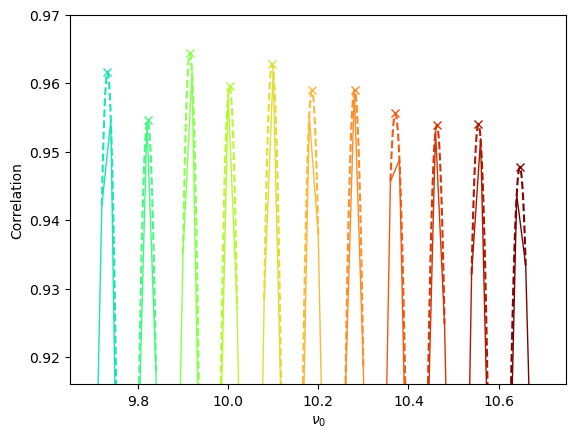

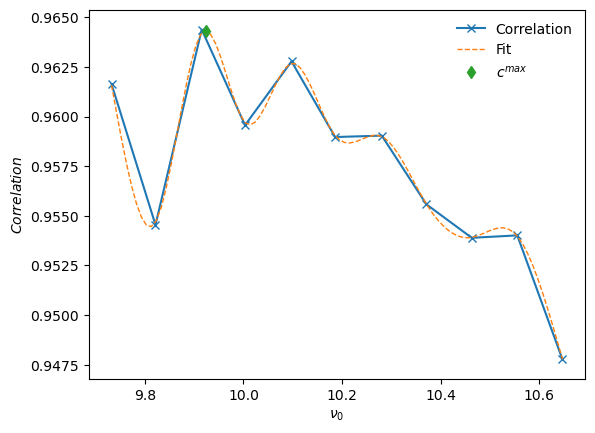

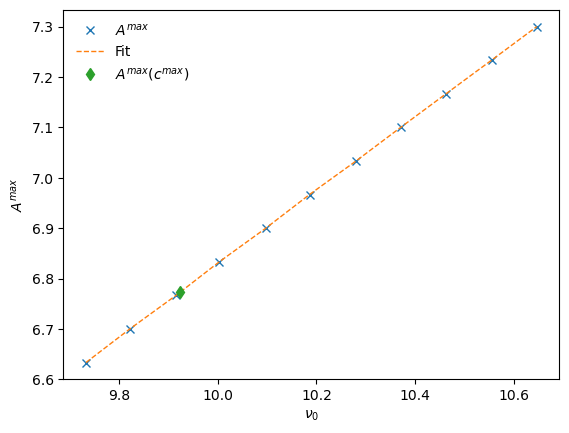

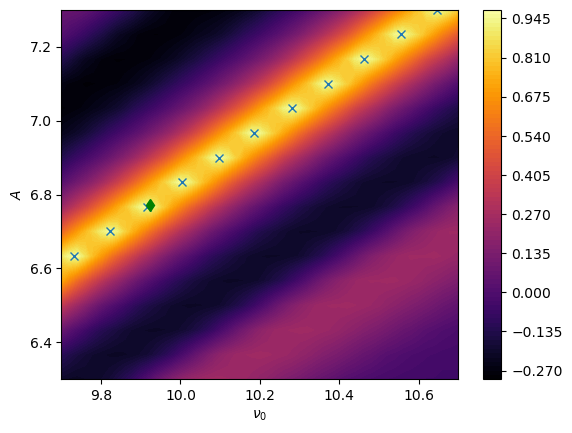

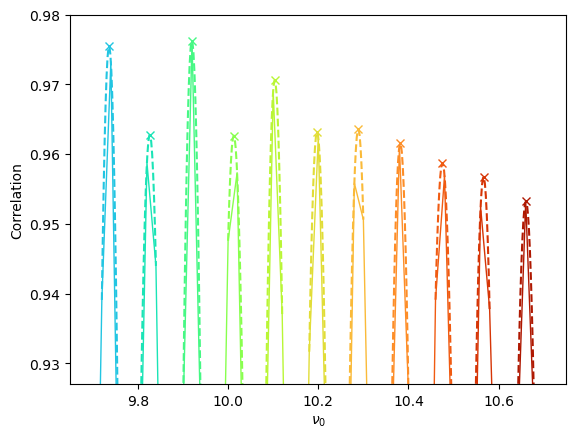

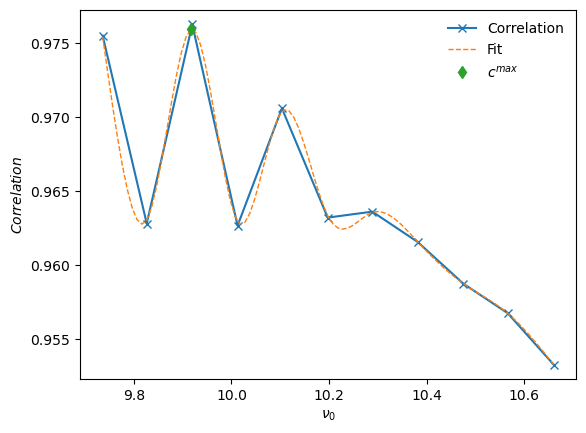

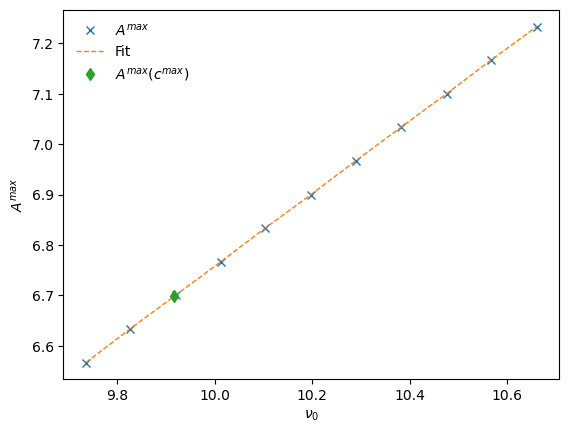

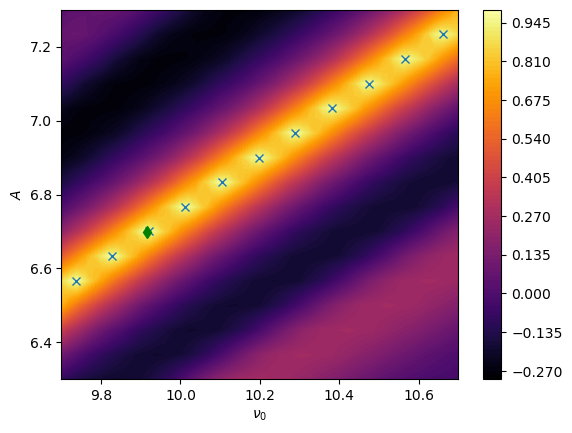

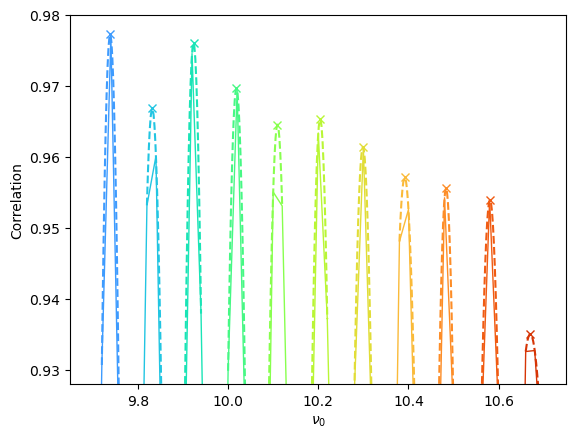

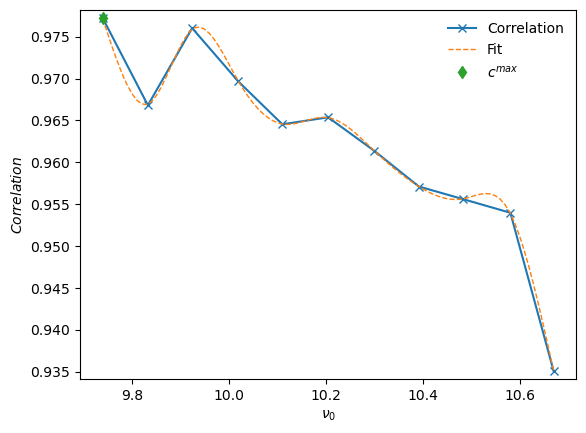

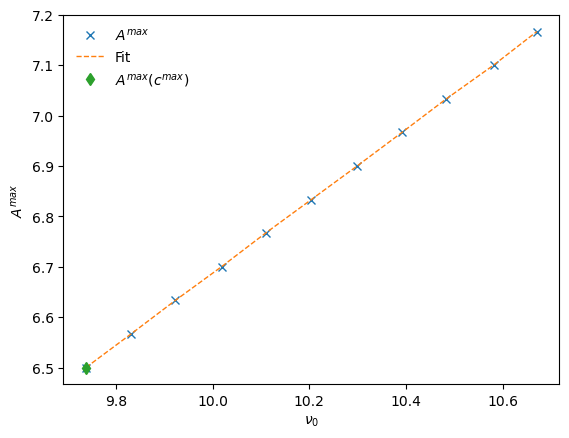

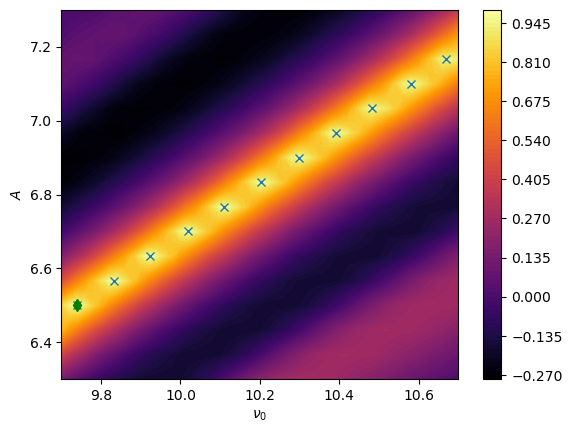

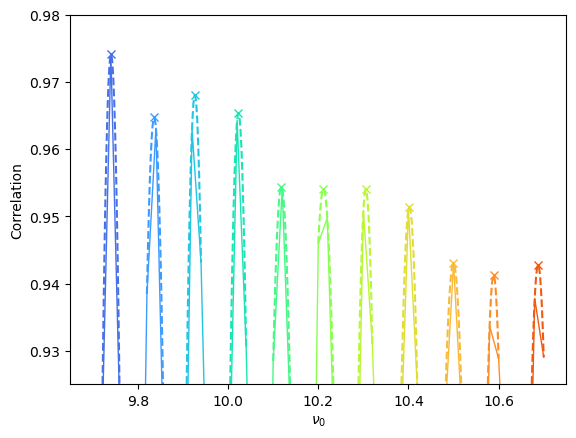

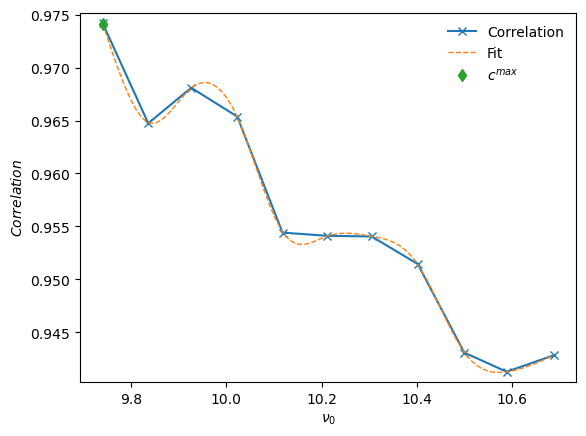

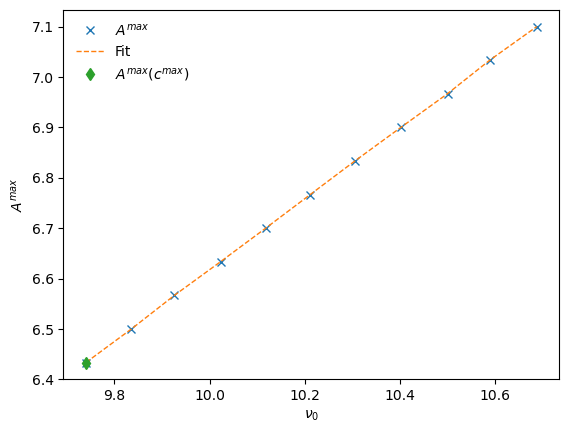

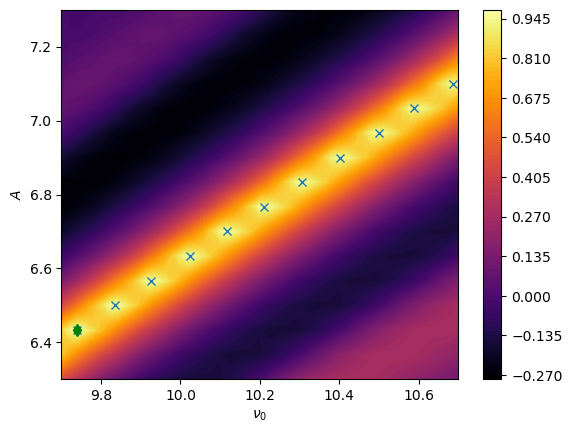

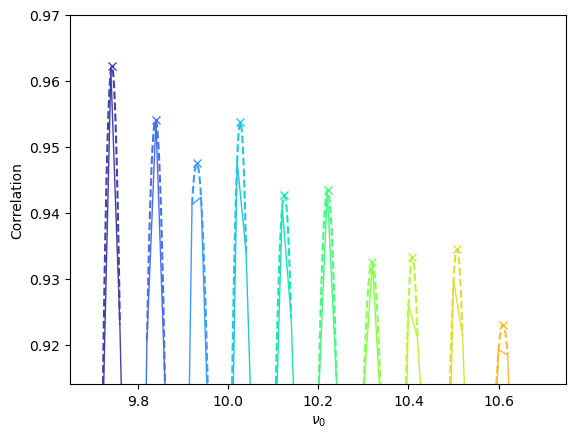

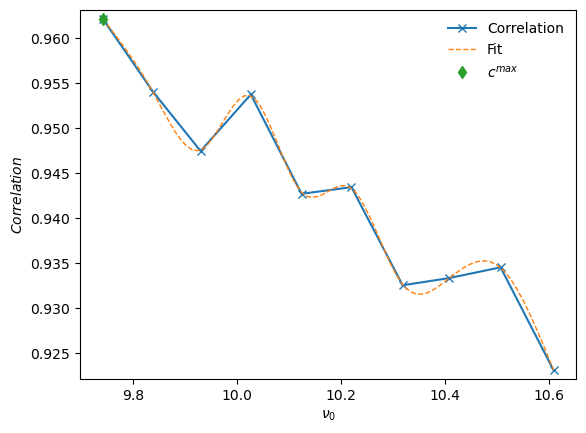

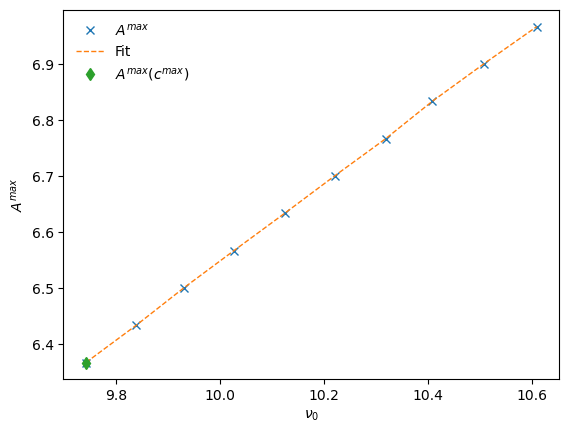

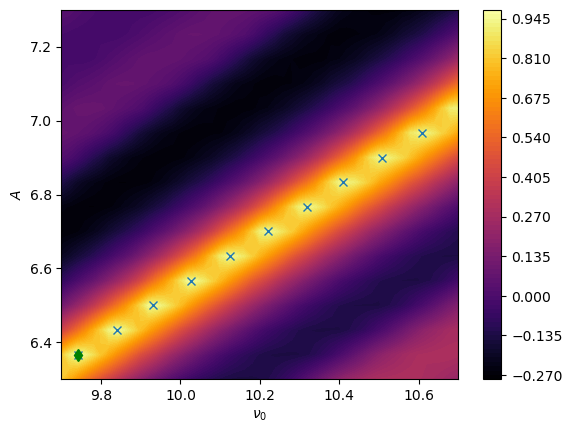

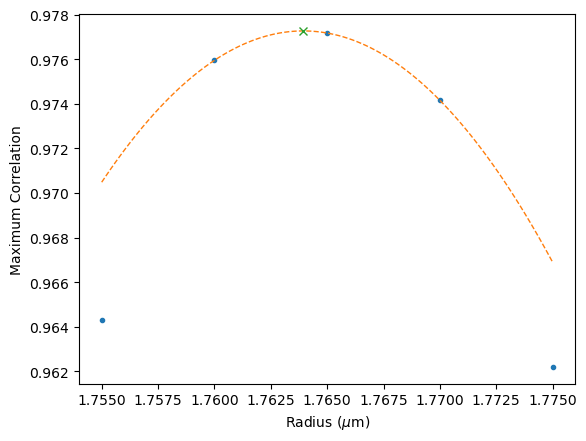

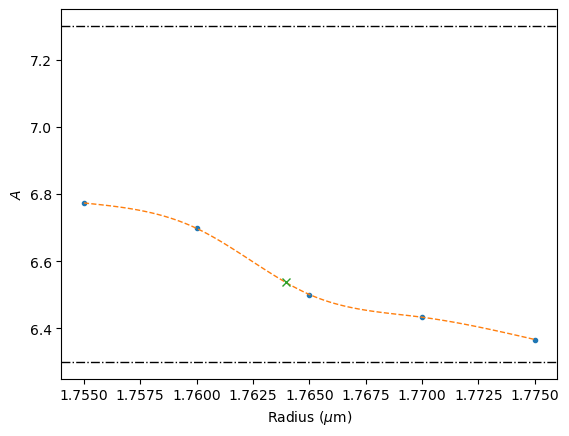

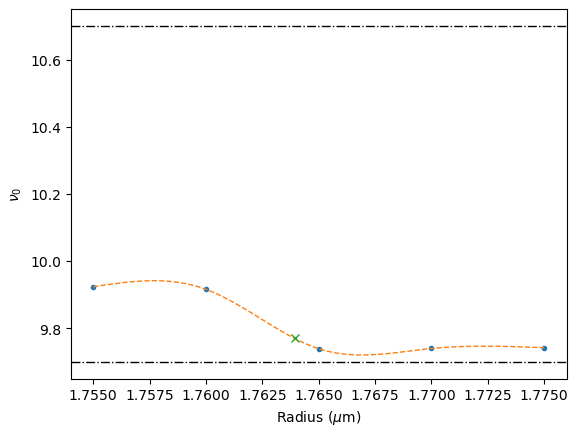

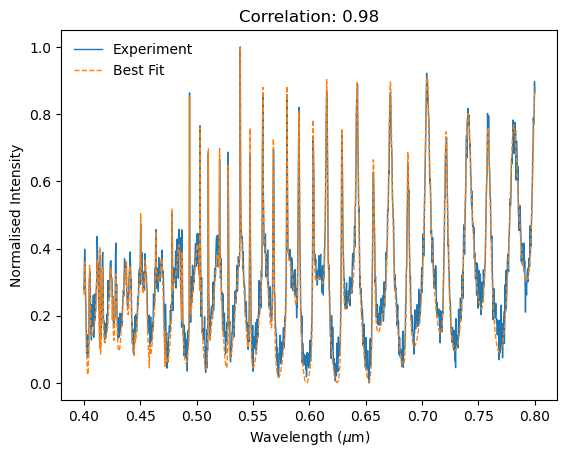

In [ ]:
if show_examples:
    ind = np.random.randint(0,len(spectra)-1)
    speci = spectra[ind]
    centrepoint = np.searchsorted(rpts, rsmooth[ind]) #find radius grid point which is rough guess
    if (centrepoint > 1) & (centrepoint < len(rpts)-2):
        rrange = np.linspace(centrepoint-2,centrepoint+2,5,dtype=int) #take two points either side of rough guess
    elif centrepoint <= 1: 
        rrange = np.linspace(0,4,5,dtype=int) #if only one point on lower side of rough guess, take five lowest radius points
    elif centrepoint >= len(rpts)-2: 
        rrange = np.linspace(-5,-1,5,dtype=int) #if only one point on higher side of rough guess, take five highest points
    rptsi = rpts[rrange] #take necessary radius values from grid points
    specgridred = [] #take necessary spectra from calculated grid points
    for rr in rrange:
        specgridred.append(specgrid[rr])
    corrvals = []
    Apoints = []
    nupoints = []
    cpoints = []
    nufinepoints = []
    cfinepoints = []
    Afinepoints = []
    cpeak = np.zeros_like(rptsi)
    Apeak = np.zeros_like(cpeak)
    nupeak = np.zeros_like(cpeak) #space for integrated correlation, and values of A and nu at maximum for each radius
    for i1 in range(len(rptsi)):
        colours = BLS.colour_subset(len(Apts), 'turbo')
        corr = np.zeros((len(Apts),len(nupts))) #space for correlations
        for i2 in range(len(Apts)):
            for i3 in range(len(nupts)):
                corr[i2,i3] = BLS.Pearson_CC(speci, np.squeeze(specgridred[i1][i2,i3,:])) #correlation between experimental spectrum and selected calculated spectrum
        corrvals.append(corr)
        Amaxima = []
        numaxima = []
        cmaxima = [] #space for A and nu coordinates of correlation 
        for i2 in range(len(Apts)):
            if (np.nanmax(corr[i2,:]) != corr[i2,~np.isnan(corr[i2,:])][0]) & (np.nanmax(corr[i2,:]) != corr[i2,~np.isnan(corr[i2,:])][-1]):
                maxcoord = np.argmax(corr[i2,:])
                nuptsfine = np.linspace(nupts[maxcoord-1],nupts[maxcoord+1],20)
                numax, cmax = BLS.parabolic_interpolation_xy(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2])
                nupol = np.polynomial.Polynomial.fit(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2],deg=2)
                Amaxima.append(Apts[i2])
                numaxima.append(numax)
                cmaxima.append(cmax)
                plt.plot(nupts, corr[i2,:], linewidth=1, color=colours[i2,:])
                plt.plot(nuptsfine, nupol(nuptsfine), '--', color=colours[i2,:])
                plt.plot(numax, cmax, 'x', markersize=6, color=colours[i2,:])
        plt.xlabel(r'$\nu_0$')
        plt.ylabel('Correlation')
        plt.ylim([np.round(0.95*np.asarray(cmaxima).max(),3), np.round(np.asarray(cmaxima).max()+0.005,2)])
        plt.show()
        if len(Amaxima) == 0: #bug fix for if no maxima found
            maxcoord = np.unravel_index(np.argmax(corr), np.shape(corr))
            Amaxima.append(Apts[maxcoord[0]])
            numaxima.append(nupts[maxcoord[1]])
            cmaxima.append(corr[maxcoord])
        Amaxima = np.array(Amaxima)
        numaxima = np.array(numaxima)
        cmaxima = np.array(cmaxima) #change lists to arrays 
        if cmaxima.max() > 0:
            primary = cmaxima > 0.9*cmaxima.max()
        else:
            primary = cmaxima > 1.1*cmaxima.max()
        Amaxima = Amaxima[primary]
        numaxima = numaxima[primary]
        cmaxima = cmaxima[primary]
        Apoints.append(Amaxima)
        nupoints.append(numaxima)
        cpoints.append(cmaxima)
        if (len(cmaxima) >= 5) & (np.sum(numaxima == np.sort(numaxima)) == len(numaxima)):
            nufine = np.linspace(numaxima.min(),numaxima.max(),int(((numaxima.max()-numaxima.min())/0.01)+1))
            cfit = sp.interpolate.make_smoothing_spline(numaxima, cmaxima, lam=1e-6)
            cinterp = cfit(nufine)
            maxind = np.argmax(cinterp)
            cpeak[i1] = cinterp[maxind]
            Apeak[i1] = np.interp(nufine[maxind], numaxima, Amaxima)
            nupeak[i1] = nufine[maxind]
            nufinepoints.append(nufine)
            Afinepoints.append(np.interp(nufine, numaxima, Amaxima))
            cfinepoints.append(cinterp)
            plt.plot(numaxima, cmaxima, marker='x', markersize=6, label='Correlation')
            plt.plot(nufine, cinterp, '--', linewidth=1, label='Fit')
            plt.plot(nupeak[i1], cpeak[i1], 'd', markersize=6, label=r'$c^{max}$')
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$Correlation$')
            plt.legend(facecolor='white', edgecolor='white', framealpha=1)
            plt.ylim([cmaxima.min()-1e-3, cmaxima.max()+1e-3])
            plt.show()
            plt.plot(numaxima,Amaxima,'x',markersize=6, label=r'$A^{max}$')
            plt.plot(nufine,np.interp(nufine, numaxima, Amaxima),'--',linewidth=1, label='Fit')
            plt.plot(nufine[maxind],np.interp(nufine[maxind], numaxima, Amaxima), 'd', markersize=6, label=r'$A^{max}(c^{max})$')
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$A^{max}$')
            plt.legend(facecolor='white', edgecolor='white', framealpha=1)
            plt.show()
            plt.contourf(nupts, Apts, corr, 100, cmap='inferno')
            plt.colorbar()
            plt.plot(numaxima, Amaxima, 'x')
            plt.plot(nufine[maxind],np.interp(nufine[maxind], numaxima, Amaxima),'gd',markersize=6)
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$A$')
            plt.show()
        elif (len(cmaxima) <= 4) | (np.sum(numaxima == np.sort(numaxima)) < len(numaxima)):
            maxind = np.argmax(cmaxima)
            cpeak[i1] = cmaxima[maxind]
            Apeak[i1] = Amaxima[maxind]
            nupeak[i1] = numaxima[maxind]
            plt.plot(numaxima, cmaxima, marker='x', markersize=6, linestyle='--', linewidth=1, label='Correlation')
            plt.plot(numaxima[maxind], cmaxima[maxind], 'd', markersize=6, label=r'$c^{max}$')
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$Correlation$')
            plt.legend(facecolor='white', edgecolor='white', framealpha=1)
            plt.ylim([cmaxima.min()-1e-3, cmaxima.max()+1e-3])
            plt.show()
            plt.plot(numaxima,Amaxima, marker='x',markersize=6, linestyle='--', linewidth=1, label=r'$A^{max}$')
            plt.plot(numaxima[maxind], Amaxima[maxind], 'd', markersize=6, label=r'$A^{max}(c^{max})$')
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$A^{max}$')
            plt.legend(facecolor='white', edgecolor='white', framealpha=1)
            plt.show()
            plt.contourf(nupts, Apts, corr, 100, cmap='inferno')
            plt.colorbar()
            plt.plot(numaxima, Amaxima, 'x')
            plt.plot(numaxima[maxind],Amaxima[maxind],'gd',markersize=6)
            plt.xlabel(r'$\nu_0$')
            plt.ylabel(r'$A$')
            plt.show()
    while (cpeak[0] == cpeak.max()) | (cpeak[-1] == cpeak.max()): #if maximum integrated correlation is at extreme of radius range, rough guess was probably a little off, so repeat but centred around maximum point from first search
        centrepoint = np.searchsorted(rpts, rptsi[cpeak == cpeak.max()])[0]
        if (centrepoint > 1) & (centrepoint < len(rpts)-2):
            rrange = np.linspace(centrepoint-2,centrepoint+2,5,dtype=int)
        elif centrepoint <= 1: 
            rrange = np.linspace(0,4,5,dtype=int)
        elif centrepoint >= len(rpts)-2: 
            rrange = np.linspace(-5,-1,5,dtype=int)
        rptsi = rpts[rrange] #take necessary radius values from grid points
        specgridred = [] #take necessary spectra from calculated grid points
        for rr in rrange:
            specgridred.append(specgrid[rr])
        cpeak = np.zeros_like(rptsi)
        Apeak = np.zeros_like(cpeak)
        nupeak = np.zeros_like(cpeak)
        for i1 in range(len(rptsi)):
            colours = BLS.colour_subset(len(Apts), 'turbo')
            corr = np.zeros((len(Apts),len(nupts))) #space for correlations
            for i2 in range(len(Apts)):
                for i3 in range(len(nupts)):
                    corr[i2,i3] = BLS.Pearson_CC(speci, specgridred[i1][i2,i3,:]) #correlation between experimental spectrum and selected calculated spectrum
            Amaxima = []
            numaxima = []
            cmaxima = []
            for i2 in range(len(Apts)):
                if (np.nanmax(corr[i2,:]) != corr[i2,~np.isnan(corr[i2,:])][0]) & (np.nanmax(corr[i2,:]) != corr[i2,~np.isnan(corr[i2,:])][-1]):
                    maxcoord = np.argmax(corr[i2,:])
                    nuptsfine = np.linspace(nupts[maxcoord-1],nupts[maxcoord+1],20)
                    numax, cmax = BLS.parabolic_interpolation_xy(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2])
                    nupol = np.polynomial.Polynomial.fit(nupts[maxcoord-1:maxcoord+2], corr[i2,maxcoord-1:maxcoord+2],deg=2)
                    Amaxima.append(Apts[i2])
                    numaxima.append(numax)
                    cmaxima.append(cmax)
                    plt.plot(nupts, corr[i2,:], linewidth=1, color=colours[i2,:])
                    plt.plot(nuptsfine, nupol(nuptsfine), '--', color=colours[i2,:])
                    plt.plot(numax, cmax, 'x', markersize=6, color=colours[i2,:])
            plt.ylim([np.round(0.95*np.asarray(cmaxima).max(),3), np.round(np.asarray(cmaxima).max()+0.005,2)])
            plt.xlabel(r'$\nu_0$')
            plt.ylabel('Correlation')
            plt.show()
            if len(Amaxima) == 0: #bug fix for if no maxima found
                maxcoord = np.unravel_index(np.argmax(corr), np.shape(corr))
                Amaxima.append(Apts[maxcoord[0]])
                numaxima.append(nupts[maxcoord[1]])
                cmaxima.append(corr[maxcoord])
            Amaxima = np.array(Amaxima)
            numaxima = np.array(numaxima)
            cmaxima = np.array(cmaxima) #change lists to arrays (necessary for argsort to work)
            if cmaxima.max() > 0:
                primary = cmaxima > 0.9*cmaxima.max()
            else:
                primary = cmaxima > 1.1*cmaxima.max()
            Amaxima = Amaxima[primary]
            numaxima = numaxima[primary]
            cmaxima = cmaxima[primary]
            if (len(cmaxima) >= 5) & (np.sum(numaxima == np.sort(numaxima)) == len(numaxima)):
                nufine = np.linspace(numaxima.min(),numaxima.max(),int(((numaxima.max()-numaxima.min())/0.01)+1))
                cfit = sp.interpolate.make_smoothing_spline(numaxima, cmaxima, lam=1e-6)
                cinterp = cfit(nufine)
                maxind = np.argmax(cinterp)
                cpeak[i1] = cinterp[maxind]
                Apeak[i1] = np.interp(nufine[maxind], numaxima, Amaxima)
                nupeak[i1] = nufine[maxind]
                plt.plot(numaxima, cmaxima, marker='x', markersize=6, label='Correlation')
                plt.plot(nufine, cinterp, '--', linewidth=1, label='Fit')
                plt.plot(nupeak[i1], cpeak[i1], 'd', markersize=6, label=r'$c^{max}$')
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$Correlation$')
                plt.legend(facecolor='white', edgecolor='white', framealpha=1)
                plt.ylim([cmaxima.min()-1e-3, cmaxima.max()+1e-3])
                plt.show()
                plt.plot(numaxima,Amaxima,'x',markersize=6, label=r'$A^{max}$')
                plt.plot(nufine,np.interp(nufine, numaxima, Amaxima),'--',linewidth=1, label='Fit')
                plt.plot(nufine[maxind],np.interp(nufine[maxind], numaxima, Amaxima), 'd', markersize=6, label=r'$A^{max}(c^{max})$')
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$A^{max}$')
                plt.legend(facecolor='white', edgecolor='white', framealpha=1)
                plt.show()
                plt.contourf(nupts, Apts, corr, 100, cmap='inferno')
                plt.colorbar()
                plt.plot(numaxima, Amaxima, 'x')
                plt.plot(nufine[maxind],np.interp(nufine[maxind], numaxima, Amaxima),'gd',markersize=6)
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$A$')
                plt.show()
            elif (len(cmaxima) <= 4) | (np.sum(numaxima == np.sort(numaxima)) < len(numaxima)):
                maxind = np.argmax(cmaxima)
                cpeak[i1] = cmaxima[maxind]
                Apeak[i1] = Amaxima[maxind]
                nupeak[i1] = numaxima[maxind]
                plt.plot(numaxima, cmaxima, marker='x', markersize=6, linestyle='--', linewidth=1, label='Correlation')
                plt.plot(numaxima[maxind], cmaxima[maxind], 'd', markersize=6, label=r'$c^{max}$')
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$Correlation$')
                plt.legend(facecolor='white', edgecolor='white', framealpha=1)
                plt.ylim([cmaxima.min()-1e-3, cmaxima.max()+1e-3])
                plt.show()
                plt.plot(numaxima,Amaxima, marker='x',markersize=6, linestyle='--', linewidth=1, label=r'$A^{max}$')
                plt.plot(numaxima[maxind], Amaxima[maxind], 'd', markersize=6, label=r'$A^{max}(c^{max})$')
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$A^{max}$')
                plt.legend(facecolor='white', edgecolor='white', framealpha=1)
                plt.show()
                plt.contourf(nupts, Apts, corr, 100, cmap='inferno')
                plt.colorbar()
                plt.plot(numaxima, Amaxima, 'x')
                plt.plot(numaxima[maxind],Amaxima[maxind],'gd',markersize=6)
                plt.xlabel(r'$\nu_0$')
                plt.ylabel(r'$A$')
                plt.show()
    maxc = np.argmax(cpeak) #find index of maximum correlation point
    rmax = BLS.parabolic_interpolation_xy(rptsi[maxc-1:maxc+2], cpeak[maxc-1:maxc+2]) #interpolate integrated correlation points to find fitted radius
    Amaxfit = sp.interpolate.make_smoothing_spline(rptsi, Apeak, lam=1e-10) #interpolate A maxima as function of radius
    numaxfit = sp.interpolate.make_smoothing_spline(rptsi, nupeak, lam=1e-10) #interpolate nu maxima as function of radius
    rpfit = np.polynomial.Polynomial.fit(rptsi[maxc-1:maxc+2], cpeak[maxc-1:maxc+2], deg=2)
    rptsplot = np.linspace(rptsi.min(),rptsi.max(),100)
    best_fit_spec = BLS.generate_spectrum(rmax[0], wl, BLS.n_osc(1/wl, Amaxfit(rmax[0]), numaxfit(rmax[0])), theta_i, phi_i, NA)
    plt.plot(rptsi, cpeak, '.', markersize=6)
    plt.plot(rptsplot, rpfit(rptsplot), '--', linewidth=1)
    plt.plot(rmax[0], rmax[1], 'x', markersize=6)
    plt.xlabel(r'Radius ($\mu$m)')
    plt.ylabel(r'Maximum Correlation')
    plt.show()
    plt.plot(rptsi, Apeak, '.', markersize=6)
    plt.plot(rptsplot, Amaxfit(rptsplot), '--', linewidth=1)
    plt.axhline(Apts.min(), linewidth=1, linestyle='-.', color='k')
    plt.axhline(Apts.max(), linewidth=1, linestyle='-.', color='k')
    plt.plot(rmax[0], Amaxfit(rmax[0]), 'x', markersize=6)
    plt.xlabel(r'Radius ($\mu$m)')
    plt.ylabel(r'$A$')
    plt.show()
    plt.plot(rptsi, nupeak, '.', markersize=6)
    plt.plot(rptsplot, numaxfit(rptsplot), '--', linewidth=1)
    plt.axhline(nupts.min(), linewidth=1, linestyle='-.', color='k')
    plt.axhline(nupts.max(), linewidth=1, linestyle='-.', color='k')
    plt.plot(rmax[0], numaxfit(rmax[0]), 'x', markersize=6)
    plt.xlabel(r'Radius ($\mu$m)')
    plt.ylabel(r'$\nu_0$')
    plt.show()
    plt.plot(wl, speci, linewidth=1, label='Experiment')
    plt.plot(wl, best_fit_spec, linewidth=1, label='Best Fit', linestyle='--')
    plt.xlabel(r'Wavelength ($\mu$m)')
    plt.ylabel(r'Normalised Intensity')
    plt.legend(facecolor='white', edgecolor='white', framealpha=1)
    plt.title(r'Correlation: ' + str(np.round(BLS.Pearson_CC(speci, best_fit_spec),3)))
    plt.show()

### Export Results

Write results to a .txt file. First column is frame number, second is approximate radius, third is approximate $A$, fourth approximate $\nu_0$, fifth is precise radius, sixth is precise $A$, seventh is precise $\nu_0$.

In [12]:
np.savetxt('output.txt', np.column_stack((frameno, rrough, Arough, nurough, rfit, Afit, nufit)))